# Linear Regression Using Analytical Approach 

## 1. Fits Regression lines for both train and test data compares their RSS
## 2. Estimates target variable for unseen indelendent variables


In [13]:
import pandas as pd


In [14]:
import numpy as np

In [15]:
house_data = pd.read_csv('kc_house_data.csv')

In [16]:
house_data.shape

(21613, 21)

In [17]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [18]:
train_data = pd.read_csv('kc_house_train_data.csv')

In [19]:
train_data.shape

(17384, 21)

In [20]:
test_data = pd.read_csv('kc_house_test_data.csv')

In [21]:
test_data.shape

(4229, 21)

## In this exercise test data is not used for evaluating the model. 
### Here it is used is used to fit another regression line.

In [22]:
# numerator is mean value of (input x output) - mean of output x mean of input 
## E [input x output] - E [output] x E[input]
## E [xy] - E[x] x E[y]
# Denominator = E[x**2] - (E[x])**2

In [23]:
def simple_linear_regression(input_feature,output):
    numerator = (input_feature * output).mean(axis=0) - (output.mean(axis=0))*(input_feature.mean(axis=0))
    denominator = (input_feature**2).mean(axis=0) - input_feature.mean(axis=0) * input_feature.mean(axis=0)
    slope = numerator/denominator
    intercept = output.mean(axis=0) - slope * (input_feature.mean(axis=0))
    return (intercept, slope)

In [24]:
sqft_living = train_data['sqft_living']
sqft_living 

0        1180
1        2570
2         770
3        1960
4        1680
         ... 
17379    3510
17380    1310
17381    1530
17382    1600
17383    1020
Name: sqft_living, Length: 17384, dtype: int64

In [25]:
# sqft_living_list = [i for i in train_data['sqft_living']]
sqft_living_list = [i for i in sqft_living]
sqft_living_list

[1180,
 2570,
 770,
 1960,
 1680,
 5420,
 1715,
 1060,
 1780,
 1890,
 3560,
 1160,
 1370,
 1810,
 1890,
 1600,
 1200,
 1250,
 1620,
 3050,
 2270,
 1070,
 2450,
 2450,
 1400,
 1520,
 2570,
 1190,
 2330,
 2060,
 2300,
 1660,
 2360,
 1220,
 2570,
 3595,
 1570,
 1280,
 3160,
 990,
 2290,
 1250,
 2753,
 1190,
 3150,
 1410,
 1980,
 2730,
 2830,
 2420,
 3250,
 1850,
 2150,
 2519,
 1540,
 1660,
 2770,
 2720,
 2240,
 1000,
 3200,
 4770,
 1260,
 2380,
 3430,
 1760,
 1040,
 1410,
 3450,
 2350,
 2020,
 1680,
 960,
 2140,
 2660,
 2770,
 1610,
 1030,
 3520,
 1200,
 1580,
 1580,
 3300,
 1160,
 1810,
 2320,
 2070,
 1980,
 2190,
 2920,
 1210,
 2340,
 1670,
 1240,
 3140,
 2310,
 1260,
 1540,
 2080,
 4380,
 1590,
 880,
 1570,
 1610,
 2400,
 1450,
 770,
 2100,
 2750,
 2100,
 2160,
 2320,
 2070,
 1060,
 2010,
 3950,
 2010,
 2140,
 1320,
 2020,
 2590,
 1190,
 1110,
 1610,
 2030,
 3670,
 2420,
 2260,
 1430,
 1360,
 1110,
 5180,
 700,
 1180,
 3960,
 2640,
 1270,
 1760,
 1780,
 3400,
 1910,
 1580,
 1340,
 2680

In [26]:
sqft_living_array = np.array(sqft_living_list)

In [27]:
sqft_living_array

array([1180, 2570,  770, ..., 1530, 1600, 1020], shape=(17384,))

In [28]:
price_list = [m for m in train_data['price']]
price_list_array = np.array(price_list)

In [29]:
price_list_array

array([221900., 538000., 180000., ..., 360000., 400000., 325000.],
      shape=(17384,))

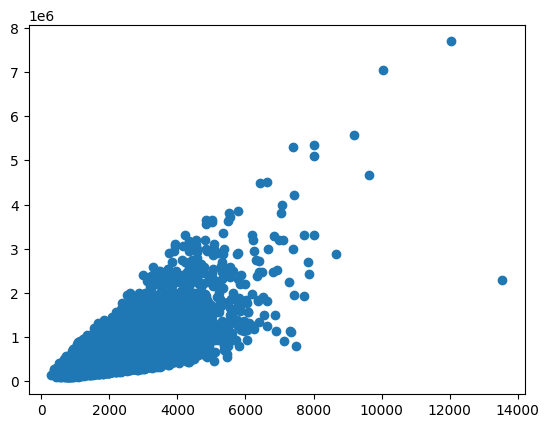

In [30]:
import matplotlib.pyplot as plt
plt.scatter(sqft_living_array, price_list_array)
plt.show()

In [31]:
intercept_sqft_living_train,slope_sqft_living_train = simple_linear_regression(sqft_living_array, price_list_array)

In [32]:
intercept_sqft_living_train

np.float64(-47116.07907289488)

In [33]:
slope_sqft_living_train

np.float64(281.95883963034294)

In [34]:
sqft_living.head()

0    1180
1    2570
2     770
3    1960
4    1680
Name: sqft_living, dtype: int64

In [35]:
# Draw the regression line with the computed slope and intercepts using matplotlib

In [36]:
def get_regression_predictions(input_feature, intercept, slope):
    predicted_output = intercept + input_feature * slope
    return(predicted_output)

In [37]:
# use function to calcuate the estimated slope and intercept on the training data to predict 'price'given 'sqft_living'   
input_feature = 2650
print (get_regression_predictions(2650, intercept_sqft_living_train, slope_sqft_living_train))

700074.8459475139


In [38]:
# round the above predicted output to one decimal

In [39]:
# What is the RSS for the simple linear regression using squarefeet to predict prices on TRAINING data
def get_residual_sum_of_squares(input_feature, output, intercept,slope):
    RSS = (((intercept + input_feature*slope) - output)**2).sum(axis=0)
    return(RSS)

In [40]:
print (get_residual_sum_of_squares(sqft_living_array,price_list_array,intercept_sqft_living_train,slope_sqft_living_train))

1201918354177283.0


In [41]:
# Calculate and print the error_array = (predicted_output - actual_output)

In [42]:
# what is the estimated square-feet for a house costing $800,000?
def inverse_regression_predictions(output, intercept, slope):
    estimated_input = (output - intercept)/slope
    return(estimated_input)

In [43]:
output = 800000
print (inverse_regression_predictions(output,intercept_sqft_living_train,slope_sqft_living_train))

3004.3962451522752


In [44]:
# Fit a regression line to the test data using sqft_living feature
# Find slope and intercept and compare the vaues to the slope and intercept obtained from train data.
# Find RSS_sqft_living_test on this test data

In [45]:
# Fit a regression line to the test data using bedrooms feature
# Find slope and intercept and compare the vaues to the slope and intercept obtaines from train data.
# Find RSS_bedrooms_test on this test data 

In [46]:
# compare and comment RSS_sqft_living_test and RSS_bedrooms_test

In [47]:
# Which model (square feet or bedrooms) has lowest RSS on TEST data? 
sqft_living_array_test = np.array([a for a in test_data['sqft_living']])
bedrooms_array_test = np.array([b for b in test_data['bedrooms']])
price_array_test = np.array([c for c in test_data['price']])
intercept_sqf,slope_sqf = simple_linear_regression(sqft_living_array_test,price_array_test)
intercept_sqf, slope_sqf

(np.float64(-28639.897221540334), np.float64(274.93662162084127))

In [48]:
intercept_br, slope_br = simple_linear_regression(bedrooms_array_test,price_array_test)
intercept_br, slope_br

(np.float64(196298.52650369075), np.float64(102683.92125312597))

In [49]:
RSS_sqf = get_residual_sum_of_squares(sqft_living_array_test,price_array_test,intercept_sqf,slope_sqf)
RSS_br = get_residual_sum_of_squares(bedrooms_array_test,price_array_test,intercept_br,slope_br)

In [50]:
RSS_sqf

np.float64(275168573899671.78)

In [51]:
RSS_br

np.float64(490597142829587.5)

In [52]:
print (RSS_sqf - RSS_br)

-215428568929915.72


In [53]:
bedrooms_array_test


array([3, 4, 3, ..., 4, 4, 2], shape=(4229,))

In [54]:
# Fit a regression line to the test data using sqft_living feature
# Find slope and intercept and compare teh vaues to the slope and intercept obtaines from train data.
# Find RSS_sqft_living_test on this test data

In [55]:
# Fit a regression line to the test data using sqft_living feature
# Find slope and intercept and compare teh vaues to the slope and intercept obtaines from train data.
# Find RSS_sqft_living_test on this test data